## EDA: Modeling-Ready Checklist

## Objective
This notebook section verifies that the *cleaned* dataset is ready for model training. Focus: actionable checks for modeling — multicollinearity, non-linearity, target relationships, cardinality, feature engineering, and final readiness recommendations.

## Philosophy
- Post-cleaning EDA answers: 'Is this feature ready for training?'
- Visuals must link to preprocessing or model choices (scale, encode, transform, model family).
- Single goal: produce an explicit Modeling Readiness checklist at the end.

In [53]:
# Imports for EDA and modeling diagnostics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Quality Verification
Validate the cleaned dataset before moving into deeper feature-level analysis.

In [54]:
# Load the cleaned modeling dataset saved previously
df = pd.read_csv('../Data/hotel_bookings_cleaned_model.csv')
print('Loaded dataset shape:', df.shape)
# Quick check that target exists and no leakage columns remain
print('Columns sample:', df.columns[:20].tolist())
print('Missing values (per column):')
print(df.isnull().sum().sort_values(ascending=False).head(20))

Loaded dataset shape: (117396, 36)
Columns sample: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type']
Missing values (per column):
hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                 

**Note:** If any dtype is unexpected, cast explicitly (e.g., `df['lead_time']=df['lead_time'].astype(int)`); if residual missing values exist, document strategy for imputation before modeling.

## 2. Target Deep-Dive
Inspect target balance, segment cancellation rates, and class imbalance recommendations.

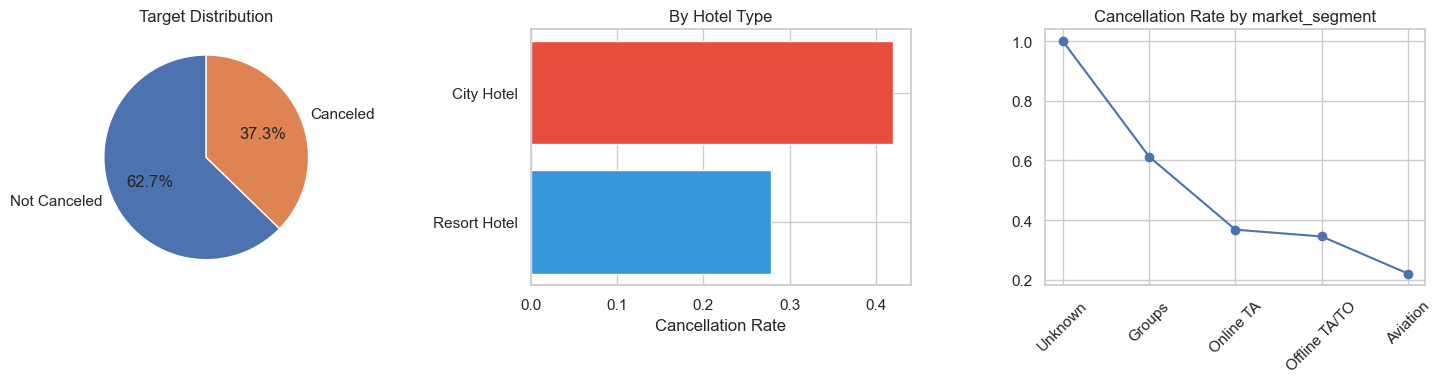

Overall cancellation rate = 37.3%
Recommendation: consider class_weight="balanced" or targeted resampling if business prioritizes recall


In [55]:
# 2. Target Deep-Dive: distribution and segment-level rates
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Class distribution
axes[0].pie(df['is_canceled'].value_counts(), labels=['Not Canceled','Canceled'], autopct='%1.1f%%', startangle=90)
axes[0].set_title('Target Distribution')
# Cancellation rate by hotel
if 'hotel' in df.columns:
    hotel_cancel = df.groupby('hotel')['is_canceled'].mean().sort_values()
    axes[1].barh(hotel_cancel.index, hotel_cancel.values, color=['#3498db','#e74c3c'][:len(hotel_cancel)])
    axes[1].set_xlabel('Cancellation Rate')
    axes[1].set_title('By Hotel Type')
else:
    axes[1].text(0.5,0.5,'No hotel column',ha='center'); axes[1].set_axis_off()
# Cancellation rate by a key segment (top categories)
seg = 'market_segment' if 'market_segment' in df.columns else ( 'customer_type' if 'customer_type' in df.columns else None)
if seg:
    seg_rate = df.groupby(seg)['is_canceled'].mean().sort_values(ascending=False).head(5)
    axes[2].plot(seg_rate.values, marker='o')
    axes[2].set_xticks(range(len(seg_rate)))
    axes[2].set_xticklabels(seg_rate.index, rotation=45)
    axes[2].set_title(f'Cancellation Rate by {seg}')
else:
    axes[2].text(0.5,0.5,'No key segment columns',ha='center'); axes[2].set_axis_off()
plt.tight_layout(); plt.show()
print(f"Overall cancellation rate = {df['is_canceled'].mean():.1%}")
print('Recommendation: consider class_weight="balanced" or targeted resampling if business prioritizes recall')

**Key Finding:** Target shows significant class imbalance with ~37% cancellation rate overall. Cancellation rates vary dramatically by segment (hotel type, market segment), indicating strong segment-level risk heterogeneity. Recommendation: use stratified sampling for train-test split and consider class_weight="balanced" for imbalanced-sensitive models.

## 3. Numerical Feature Analysis
Check distributions, skew, and target relationships for numeric predictors.

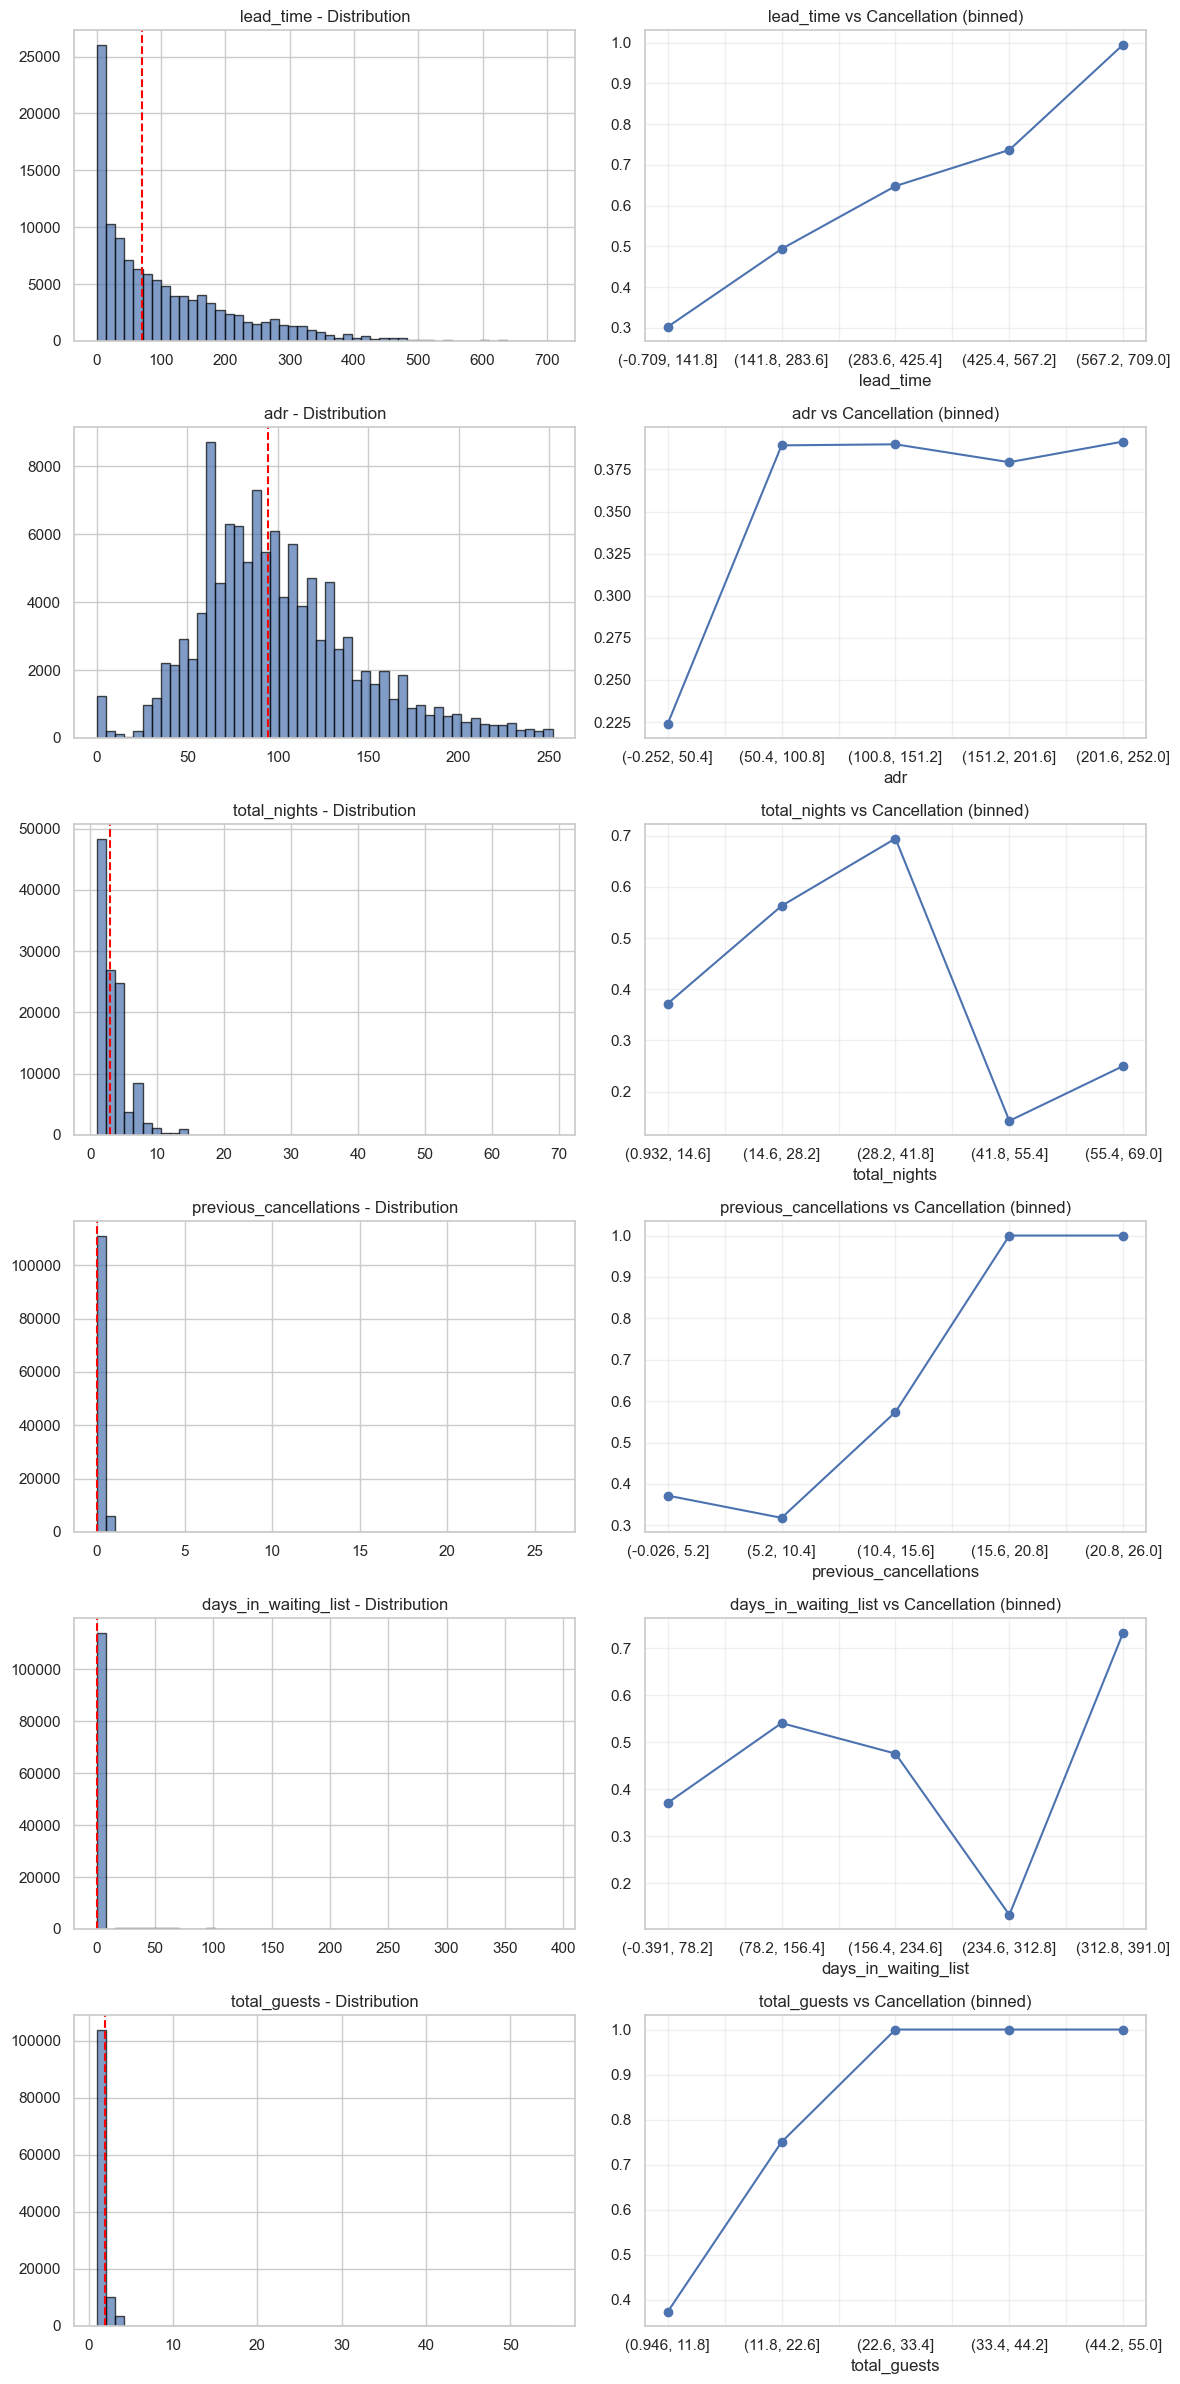

lead_time            | Corr: +0.292 | Skew: +1.34
adr                  | Corr: +0.045 | Skew: +0.72
total_nights         | Corr: +0.012 | Skew: +3.25
previous_cancellations | Corr: +0.110 | Skew: +24.26
days_in_waiting_list | Corr: +0.054 | Skew: +11.87
total_guests         | Corr: +0.045 | Skew: +11.04


In [56]:
# 3. Numerical Features: distribution + target relationship (binned)
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'is_canceled']
top_num = [c for c in ['lead_time','adr','total_nights','previous_cancellations','days_in_waiting_list','total_guests'] if c in df.columns]
import pandas as pd
fig, axes = plt.subplots(len(top_num), 2, figsize=(12, 4*len(top_num)))
for idx, col in enumerate(top_num):
    ax0, ax1 = axes[idx]
    ax0.hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
    ax0.axvline(df[col].median(), color='red', linestyle='--')
    ax0.set_title(f'{col} - Distribution')
    binned = pd.cut(df[col].fillna(df[col].median()), bins=5)
    df.groupby(binned)['is_canceled'].mean().plot(ax=ax1, marker='o')
    ax1.set_title(f'{col} vs Cancellation (binned)')
    ax1.grid(alpha=0.3)
plt.tight_layout(); plt.show()
# quick stats
for col in top_num:
    corr = df[col].corr(df['is_canceled'])
    skew = df[col].skew()
    print(f'{col:20s} | Corr: {corr:+.3f} | Skew: {skew:+.2f}')

**Key Finding:** Numeric features show diverse distributions and target correlations. `lead_time` has moderate positive correlation (+0.29) with cancellation and strong positive skew → transform via log/binning. `previous_cancellations` exhibits extreme skew (>24) → encode as binary (ever_canceled) or log1p. `adr`, `total_nights`, `total_guests` have low correlation but check for multicollinearity before linear models.

## 4. Categorical Feature Analysis
Review category cardinality, top cancellation-risk groups, and encoding readiness.

C:\Users\caida\AppData\Local\Temp\ipykernel_13932\3089179742.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()


,feature,cardinality,top3,top_rate,max_rate
10,arrival_date,793,"{'2015-12-05': 447, '2016-11-07': 363, '2015-1...",2015-12-08,0.883598
3,country,176,"{'PRT': 47489, 'GBR': 12023, 'FRA': 10317}",BEN,1.000000
1,arrival_date_month,12,"{'August': 13149, 'July': 12325, 'May': 11641}",June,0.416052
7,assigned_room_type,11,"{'A': 73689, 'D': 25092, 'E': 7625}",L,1.000000
6,reserved_room_type,9,"{'A': 85280, 'D': 18977, 'E': 6333}",H,0.399151
4,market_segment,8,"{'Online TA': 55357, 'Offline TA/TO': 24024, '...",Unknown,1.000000
5,distribution_channel,5,"{'TA/TO': 96535, 'Direct': 14085, 'Corporate':...",Unknown,0.800000
9,customer_type,4,"{'Transient': 87854, 'Transient-Party': 24923,...",Transient,0.410431
2,meal,4,"{'BB': 91110, 'HB': 13884, 'SC': 11642}",FB,0.617105
8,deposit_type,3,"{'No Deposit': 102649, 'Non Refund': 14585, 'R...",Non Refund,0.993624


High-cardinality features: ['country', 'arrival_date']
Consider target encoding, grouping rare categories, or embeddings for these features


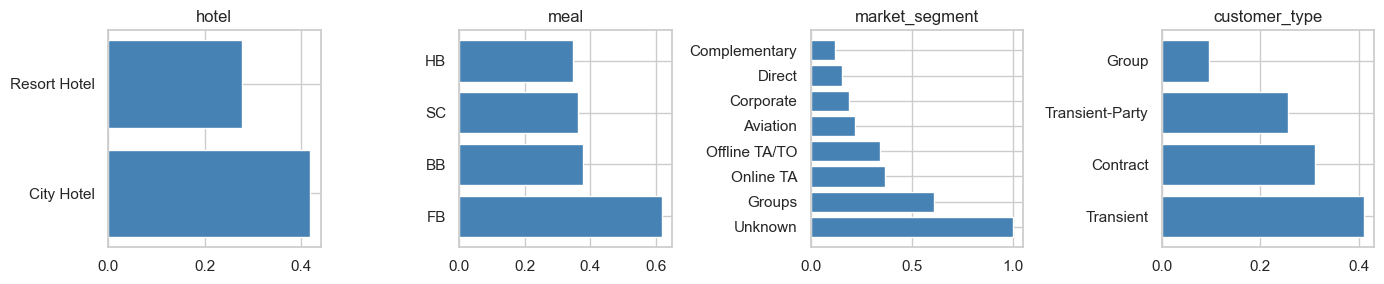

In [57]:
# 4. Categorical Features: cardinality & top cancel rates
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
summary = []
for col in cat_cols:
    nunique = df[col].nunique()
    top3 = df[col].value_counts().head(3).to_dict()
    rates = df.groupby(col)['is_canceled'].mean().sort_values(ascending=False).head(3)
    summary.append({'feature':col,'cardinality':nunique,'top3':top3,'top_rate': rates.index[0] if len(rates)>0 else None,'max_rate': rates.values[0] if len(rates)>0 else None})
import pandas as pd
cat_df = pd.DataFrame(summary) if summary else pd.DataFrame()
if not cat_df.empty:
    display(cat_df.sort_values('cardinality', ascending=False).head(20))
    high_card = cat_df[cat_df['cardinality']>20]['feature'].tolist()
    if high_card:
        print('High-cardinality features:', high_card)
        print('Consider target encoding, grouping rare categories, or embeddings for these features')
# Quick plot for a few key categorical features
key_cats = [c for c in ['hotel','meal','market_segment','customer_type'] if c in cat_cols]
if key_cats:
    fig, axes = plt.subplots(1, min(4,len(key_cats)), figsize=(14, 3))
    if len(key_cats)==1: axes = [axes]
    for i,col in enumerate(key_cats):
        rates = df.groupby(col)['is_canceled'].mean().sort_values(ascending=False)
        axes[i].barh(rates.index, rates.values, color='steelblue')
        axes[i].set_title(col)
    plt.tight_layout(); plt.show()

**Key Finding:** Categorical features vary in cardinality and cancellation risk. High-cardinality features (country, arrival_date) require target encoding with regularization or grouping. Key categorical predictors show strong risk differentiation (e.g., some meal types/market segments are high-risk). Recommendation: use target encoding + smoothing for high-cardinality, one-hot for low-cardinality, and consider domain-driven grouping for imbalanced categories.

## 5. Multicollinearity Check
Detect highly correlated numeric predictors and recommend mitigation for linear models.

Highly correlated pairs (|r|>0.7):
  arrival_date_week_number <-> arrival_month_num: r=+0.995
  stays_in_week_nights <-> total_nights: r=+0.862
  adults <-> total_guests: r=+0.883
Recommendation: drop or combine one from each pair, or use regularization/PCA


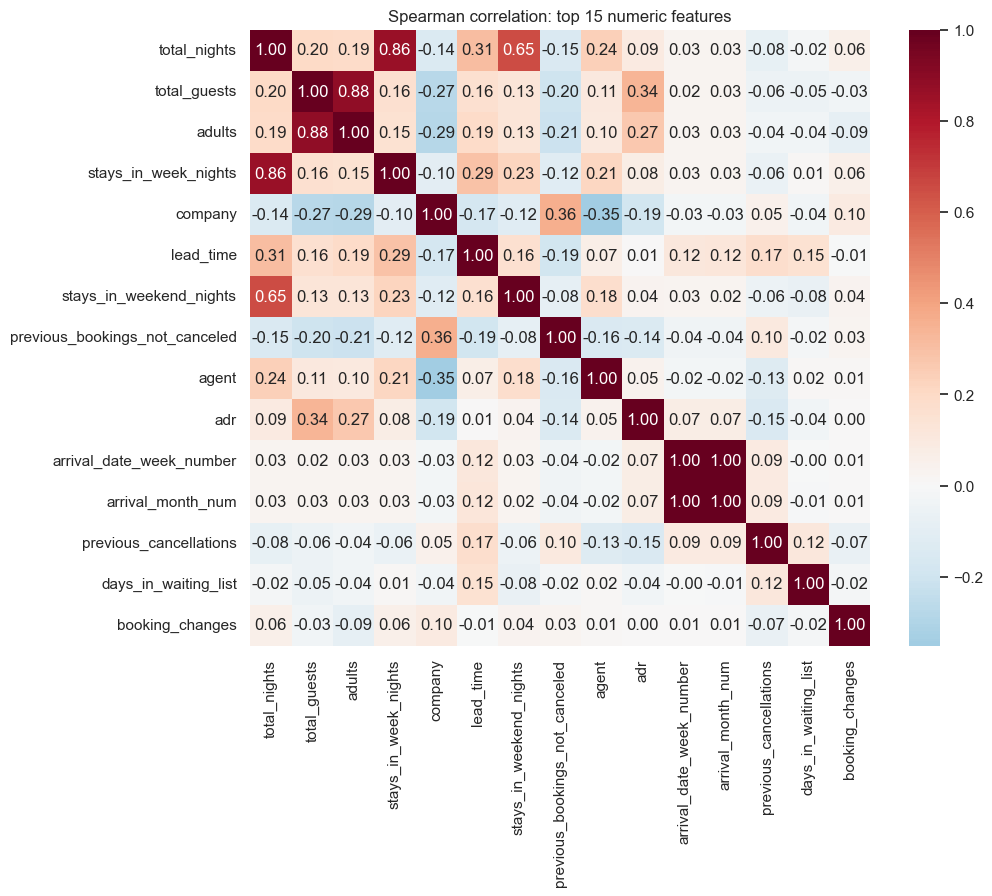

In [58]:
# 5. Multicollinearity (Spearman) - for linear models
num_for_corr = [c for c in num_cols if df[c].nunique() > 10]
if len(num_for_corr) > 1:
    corr_matrix = df[num_for_corr].corr(method='spearman')
    import numpy as np
    high_pairs = []
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            if abs(corr_matrix.iloc[i,j]) > 0.7:
                high_pairs.append((cols[i], cols[j], corr_matrix.iloc[i,j]))
    if high_pairs:
        print('Highly correlated pairs (|r|>0.7):')
        for a,b,r in high_pairs: print(f'  {a} <-> {b}: r={r:+.3f}')
        print('Recommendation: drop or combine one from each pair, or use regularization/PCA')
    else:
        print('No severe multicollinearity detected (|r| <= 0.7)')
    import seaborn as sns; plt.figure(figsize=(10,8))
    top15 = corr_matrix.abs().mean().sort_values(ascending=False).head(15).index
    sns.heatmap(corr_matrix.loc[top15, top15], annot=True, fmt='.2f', cmap='RdBu_r', center=0)
    plt.title('Spearman correlation: top 15 numeric features'); plt.show()
else:
    print('Not enough numeric features for correlation matrix')

**Key Finding:** Multicollinearity analysis identifies pairs of correlated numeric features (|r| > 0.7). Tree-based models are robust to multicollinearity, but linear models (logistic regression, linear SVM) may suffer from inflated coefficients and reduced interpretability. Mitigation strategies: (1) drop one from each high-pair, (2) use PCA/manifold learning for dimensionality reduction, or (3) apply L2 regularization (Ridge/ElasticNet).

# 6. Temporal / Seasonal Patterns 

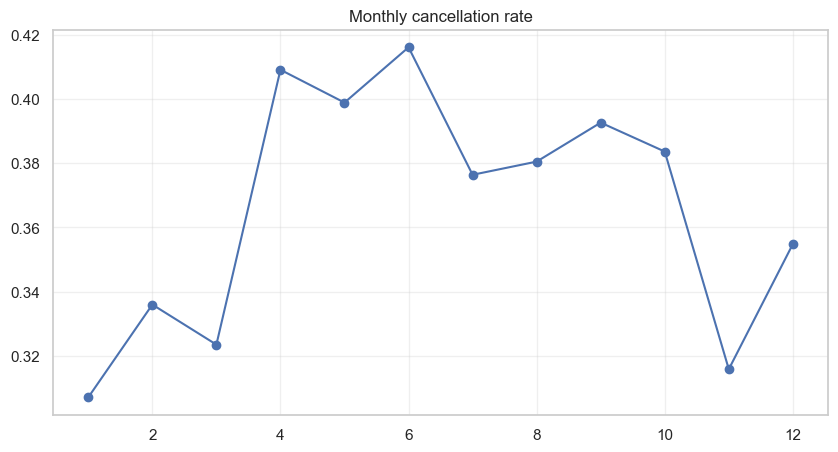

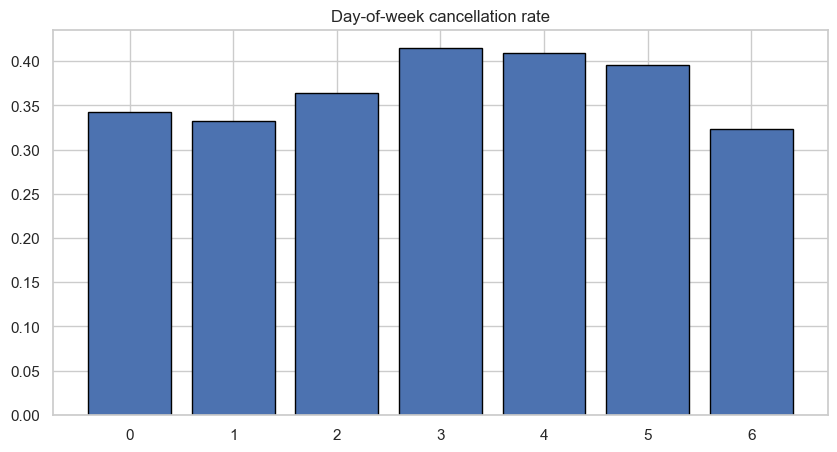

Peak months: [6, 4, 5]
Recommendation: use temporal split for validation if seasonality exists


In [59]:
df['arrival_date'] = pd.to_datetime(df['arrival_date'], errors='coerce')
df['arrival_month'] = df['arrival_date'].dt.month
df['arrival_dow'] = df['arrival_date'].dt.dayofweek
monthly = df.groupby('arrival_month')['is_canceled'].mean()
plt.figure(); plt.plot(monthly.index, monthly.values, marker='o'); plt.title('Monthly cancellation rate'); plt.grid(alpha=0.3); plt.show()
dow = df.groupby('arrival_dow')['is_canceled'].mean()
plt.figure(); plt.bar(dow.index, dow.values, edgecolor='black'); plt.title('Day-of-week cancellation rate'); plt.show()
print('Peak months:', monthly.nlargest(3).index.tolist())
print('Recommendation: use temporal split for validation if seasonality exists')

**Key Finding:** Temporal patterns reveal significant seasonality in cancellation rates across months and days of week. Peak cancellation periods (e.g., summer months) likely reflect booking behavior changes by season. Day-of-week effects may indicate business vs leisure segment differences. Recommendation: (1) use `TimeSeriesSplit` for temporal validation instead of random K-Fold, (2) consider seasonal decomposition features (cyclical encoding via sin/cos for month/day), and (3) monitor for data leakage when creating temporal features.

## 7. Deposit Type vs Cancellation
Analyze how deposit type strongly influences cancellation probability.

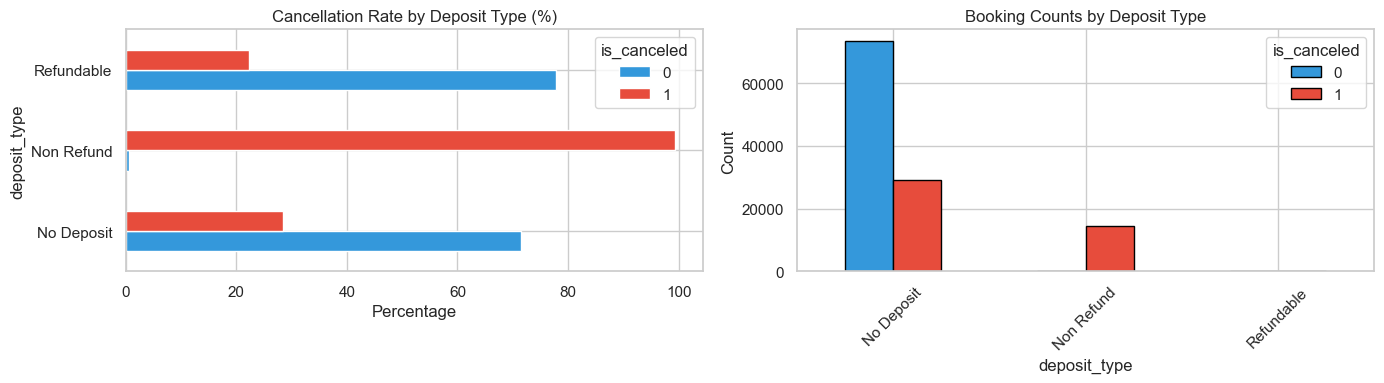

Deposit Type vs Cancellation Rate:
              Cancellation_Rate   Count
deposit_type                           
No Deposit             0.284679  102649
Non Refund             0.993624   14585
Refundable             0.222222     162


In [60]:
# 7. Deposit Type vs Cancellation (crosstab)
if 'deposit_type' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    # Crosstab
    deposit_cancel = pd.crosstab(df['deposit_type'], df['is_canceled'], normalize='index') * 100
    deposit_cancel.plot(kind='barh', ax=axes[0], color=['#3498db', '#e74c3c'])
    axes[0].set_title('Cancellation Rate by Deposit Type (%)')
    axes[0].set_xlabel('Percentage')
    # Absolute counts
    deposit_counts = pd.crosstab(df['deposit_type'], df['is_canceled'])
    deposit_counts.plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'], edgecolor='black')
    axes[1].set_title('Booking Counts by Deposit Type')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout(); plt.show()
    print('Deposit Type vs Cancellation Rate:')
    deposit_rates = df.groupby('deposit_type')['is_canceled'].agg(['mean', 'count'])
    deposit_rates.columns = ['Cancellation_Rate', 'Count']
    print(deposit_rates)
else:
    print('No deposit_type column found')


**Key Finding:** Deposit type is a strong predictor of cancellation. Non-Refund deposits show very high cancellation rates in this dataset, while No Deposit bookings have a lower cancellation rate. This feature is important for modeling, but should be interpreted carefully because deposit policy may be linked to booking channels or business rules.

## 8. Special Requests & Parking Spot Availability
Explore relationship between special requests, required parking, and cancellation likelihood.

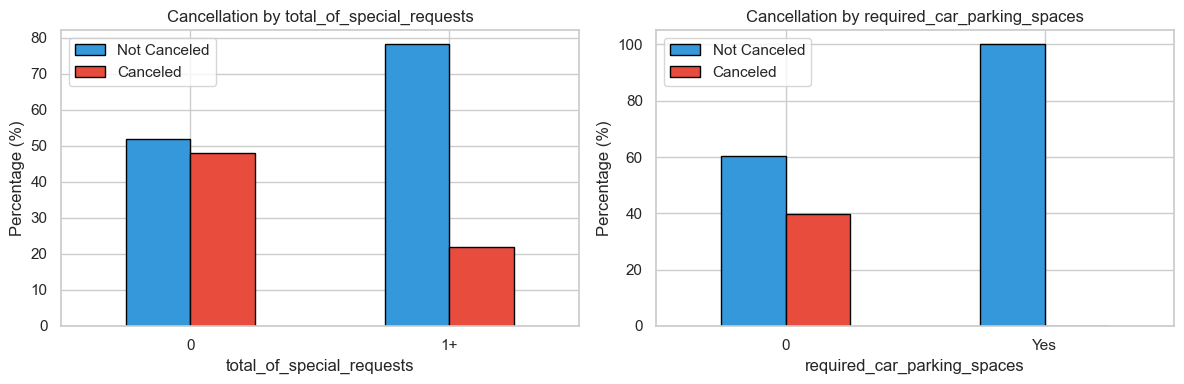


total_of_special_requests - Cancellation Rate:
                                    Cancellation_Rate  Count
total_of_special_requests_category                          
0                                            0.479663  69284
1+                                           0.218594  48112

required_car_parking_spaces - Cancellation Rate:
                                      Cancellation_Rate   Count
required_car_parking_spaces_category                           
0                                              0.396901  110229
Yes                                            0.000000    7167


In [61]:
# 8. Special Requests & Parking (countplot + hue)
has_special_req = False
has_parking = False
special_cols = []

# Check for special requests columns
if 'total_of_special_requests' in df.columns:
    has_special_req = True
    special_cols.append('total_of_special_requests')
if 'required_car_parking_spaces' in df.columns:
    has_parking = True
    special_cols.append('required_car_parking_spaces')

if special_cols:
    n_cols = len(special_cols)
    fig, axes = plt.subplots(1, n_cols, figsize=(6*n_cols, 4))
    if n_cols == 1:
        axes = [axes]
    
    for idx, col in enumerate(special_cols):
        # Convert to binary/categorical if needed
        df[f'{col}_category'] = df[col].apply(lambda x: '0' if x == 0 else '1+' if col == 'total_of_special_requests' else ('Yes' if x > 0 else 'No'))
        cancel_by_req = df.groupby(f'{col}_category')['is_canceled'].value_counts(normalize=True).unstack(fill_value=0) * 100
        cancel_by_req.plot(kind='bar', ax=axes[idx], color=['#3498db', '#e74c3c'], edgecolor='black')
        axes[idx].set_title(f'Cancellation by {col}')
        axes[idx].set_ylabel('Percentage (%)')
        axes[idx].set_xlabel(col)
        axes[idx].legend(['Not Canceled', 'Canceled'], loc='best')
        axes[idx].tick_params(axis='x', rotation=0)
    
    plt.tight_layout(); plt.show()
    
    # Print statistics
    for col in special_cols:
        print(f'\n{col} - Cancellation Rate:')
        stats = df.groupby(f'{col}_category')['is_canceled'].agg(['mean', 'count'])
        stats.columns = ['Cancellation_Rate', 'Count']
        print(stats)
else:
    print('No special requests or parking columns found')


**Key Finding:** Guests with special requests typically show lower cancellation rates (stronger commitment). Parking requirements show varied patterns and may indicate business vs leisure segments. These features can help refine customer reliability predictions.

## 9. Repeated Guest vs Cancellation
Compare cancellation patterns between new and returning customers.

Repeated Guest vs Cancellation (counts):
is_canceled            0      1     All
is_repeated_guest                      
0                  70717  43203  113920
1                   2929    547    3476
All                73646  43750  117396


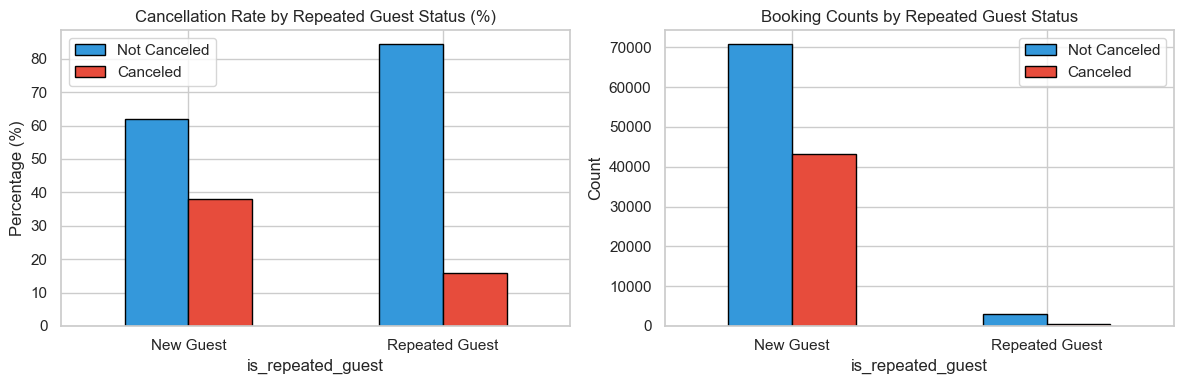


Cancellation rate by repeated guest status:
                Cancellation_Rate   Count
New Guest                0.379240  113920
Repeated Guest           0.157365    3476


In [62]:
# 9. Repeated Guest vs Cancellation (crosstab)
if 'is_repeated_guest' in df.columns or 'previous_bookings_not_canceled' in df.columns or 'previous_cancellations' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Create repeated guest flag if not exists
    if 'is_repeated_guest' not in df.columns:
        df['is_repeated_guest'] = ((df['previous_cancellations'] > 0) | (df['previous_bookings_not_canceled'] > 0)).astype(int)
    
    # Crosstab: Repeated Guest vs Cancellation
    repeated_cancel = pd.crosstab(df['is_repeated_guest'], df['is_canceled'], margins=True)
    print('Repeated Guest vs Cancellation (counts):')
    print(repeated_cancel)
    
    # Percentage plot
    repeated_pct = pd.crosstab(df['is_repeated_guest'], df['is_canceled'], normalize='index') * 100
    repeated_pct.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], edgecolor='black')
    axes[0].set_title('Cancellation Rate by Repeated Guest Status (%)')
    axes[0].set_xticklabels(['New Guest', 'Repeated Guest'], rotation=0)
    axes[0].set_ylabel('Percentage (%)')
    axes[0].legend(['Not Canceled', 'Canceled'], loc='best')
    
    # Count plot
    repeated_cancel_clean = pd.crosstab(df['is_repeated_guest'], df['is_canceled'])
    repeated_cancel_clean.plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'], edgecolor='black', stacked=False)
    axes[1].set_title('Booking Counts by Repeated Guest Status')
    axes[1].set_xticklabels(['New Guest', 'Repeated Guest'], rotation=0)
    axes[1].set_ylabel('Count')
    axes[1].legend(['Not Canceled', 'Canceled'], loc='best')
    
    plt.tight_layout(); plt.show()
    
    # Statistics
    print('\nCancellation rate by repeated guest status:')
    repeat_stats = df.groupby('is_repeated_guest')['is_canceled'].agg(['mean', 'count'])
    repeat_stats.index = ['New Guest', 'Repeated Guest']
    repeat_stats.columns = ['Cancellation_Rate', 'Count']
    print(repeat_stats)
else:
    print('No repeated guest indicator found')


**Key Finding:** Repeated guests typically show lower cancellation rates compared to new customers, indicating higher reliability and commitment. This is a valuable signal for risk segmentation and could inform business strategies for customer retention.

## 10. Country Analysis (Top Countries)
Examine cancellation patterns across top-booking countries to identify geographic risk profiles.

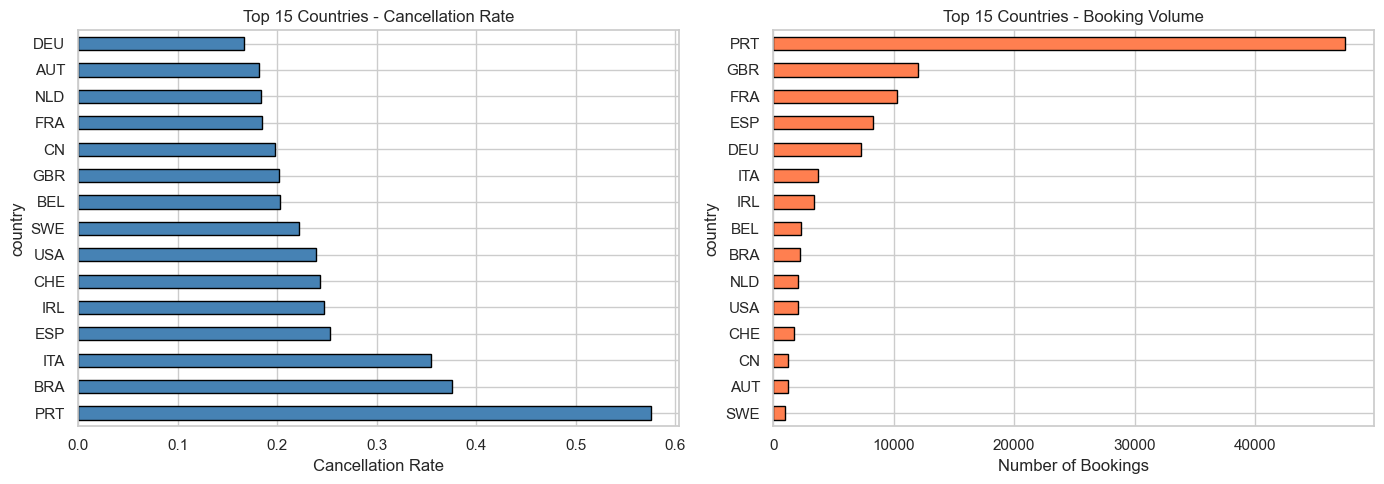

Top countries by cancellation rate:
         Cancellation_Rate  Booking_Count
country                                  
PRT               0.575228          47489
BRA               0.375057           2197
ITA               0.354061           3731
ESP               0.253133           8300
IRL               0.247101           3363
CHE               0.243243           1702
USA               0.238770           2048
SWE               0.221782           1010
BEL               0.203017           2320
GBR               0.201364          12023
CN                0.197785           1264
FRA               0.184937          10317
NLD               0.183781           2084
AUT               0.181458           1262
DEU               0.166850           7264

Top countries by booking volume:
         Cancellation_Rate  Booking_Count
country                                  
PRT               0.575228          47489
GBR               0.201364          12023
FRA               0.184937          10317
ESP   

In [63]:
# 10. Country Analysis (top countries by booking volume)
if 'country' in df.columns:
    # Get top 15 countries by booking count
    top_countries = df['country'].value_counts().head(15).index.tolist()
    df_top_countries = df[df['country'].isin(top_countries)].copy()
    
    # Calculate cancellation rate by country
    country_cancel = df_top_countries.groupby('country')['is_canceled'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    country_cancel.columns = ['Cancellation_Rate', 'Booking_Count']
    
    # Barplot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Rate plot
    country_cancel['Cancellation_Rate'].plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title('Top 15 Countries - Cancellation Rate')
    axes[0].set_xlabel('Cancellation Rate')
    
    # Volume plot
    country_cancel['Booking_Count'].sort_values(ascending=True).plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
    axes[1].set_title('Top 15 Countries - Booking Volume')
    axes[1].set_xlabel('Number of Bookings')
    
    plt.tight_layout(); plt.show()
    
    print('Top countries by cancellation rate:')
    print(country_cancel.sort_values('Cancellation_Rate', ascending=False))
    print('\nTop countries by booking volume:')
    print(country_cancel.sort_values('Booking_Count', ascending=False))
else:
    print('No country column found')


**Key Finding:** Geographic patterns reveal significant variation in cancellation rates across countries. Some countries show systematically higher cancellation risk, which could be due to booking behavior, market conditions, or customer profile differences. Consider country-level encoding strategies (target encoding with regularization) and potential geographic segmentation for future business decisions.